# ERA5 - Processing from 2 types : 
1 - ERA5 Monthly average
2 - ERA5 Monthly extrema (max and min) - built from ERA5 hourly data

# 0 - Initialization

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# CONFIGURATION
# ============================================================

RAW_DIR = Path("/home/mbaldacchino/data/era5_hourly")
PROCESSED_DIR = Path("/home/mbaldacchino/data/era5_monthly_extrema")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CLIMATE_FILE = Path("/home/mbaldacchino/data/era5_monthly_1970_2026")
CLIMATE_FILE_PROCESSED = Path("/home/mbaldacchino/data/era5_monthly_1970_2026.nc")
EXTREMA_FILE_PROCESSED = Path("/home/mbaldacchino/data/era5_monthly_extrema_1970_2026.nc")

ERA5_MONTHLY_FILE = Path("/home/mbaldacchino/data/era5_monthly_averaged_1970_2026.grib")

FINAL_FILE = Path("/home/mbaldacchino/data/era5_monthly_complete_1970_2026.nc")


# 1 - Functions

In [ ]:
def open_era5_extrema_grib(path: str | Path) -> xr.Dataset:
    """
    Open an ERA5 mx2t/mn2t GRIB and flatten the
    (time, step) forecast representation into a single
    hourly valid_time dimension.
    """

    path = Path(path)

    ds = xr.open_dataset(
        path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )

    required = {"mx2t", "mn2t"}

    missing = required - set(ds.data_vars)

    if missing:
        raise ValueError(
            f"{path.name}: missing variables {missing}. Available variables: {list(ds.data_vars)}"
        )

    # Keep only variables of interest
    ds = ds[["mx2t", "mn2t"]]

    # --------------------------------------------------------
    # Flatten:
    #
    # time × step
    #     ->
    # sample
    #
    # valid_time automatically becomes valid_time(sample)
    # during stack().
    # --------------------------------------------------------

    ds = ds.stack(sample=("time", "step"))

    # IMPORTANT:
    # valid_time already exists at this stage.
    #
    # Therefore use it as the dimension instead of trying
    # to rename "sample" -> "valid_time".
    ds = ds.swap_dims({"sample": "valid_time"})

    # Remove the now-unnecessary forecast coordinates
    ds = ds.drop_vars(
        ["sample", "time", "step"],
        errors="ignore",
    )

    # Put dimensions into a convenient order
    ds = ds.transpose(
        "valid_time",
        "latitude",
        "longitude",
    )

    ds = ds.sortby("valid_time")

    # --------------------------------------------------------
    # Sanity checks
    # --------------------------------------------------------

    times = pd.DatetimeIndex(ds.valid_time.values)

    if times.has_duplicates:
        duplicates = times[times.duplicated()].unique()

        raise ValueError(f"{path.name}: duplicate valid times found: {duplicates[:10]}")

    time_diffs = np.diff(times.values)

    if len(time_diffs) > 0:
        if not np.all(time_diffs == np.timedelta64(1, "h")):
            raise ValueError(f"{path.name}: valid_time is not continuously hourly.")

    return ds


def hourly_to_monthly_extrema(
    ds: xr.Dataset,
) -> xr.Dataset:
    """
    Convert hourly ERA5 mx2t/mn2t interval extrema into:

    - monthly mean of daily maximum 2m temperature
    - monthly mean of daily minimum 2m temperature

    Only complete days (24 hourly intervals) and complete
    calendar months are retained.
    """

    # --------------------------------------------------------
    # Assign each interval to its starting hour
    #
    # valid_time = 00:00 represents 23:00 -> 00:00,
    # therefore associate it with 23:00 of the previous day.
    # --------------------------------------------------------

    ds = ds.assign_coords(valid_time=(ds.valid_time - np.timedelta64(1, "h")))

    # --------------------------------------------------------
    # Count number of hourly intervals per calendar day
    # --------------------------------------------------------

    hourly_counter = xr.DataArray(
        np.ones(
            ds.sizes["valid_time"],
            dtype=np.uint8,
        ),
        coords={"valid_time": ds.valid_time},
        dims="valid_time",
    )

    daily_count = hourly_counter.resample(valid_time="1D").sum()

    complete_day = daily_count == 24

    # --------------------------------------------------------
    # Hourly -> daily extrema
    # --------------------------------------------------------

    daily_max = ds["mx2t"].resample(valid_time="1D").max().where(complete_day)

    daily_min = ds["mn2t"].resample(valid_time="1D").min().where(complete_day)

    # --------------------------------------------------------
    # Daily -> monthly
    # --------------------------------------------------------

    monthly_max = daily_max.resample(valid_time="MS").mean()

    monthly_min = daily_min.resample(valid_time="MS").mean()

    monthly = xr.Dataset(
        {
            "t2m_max": monthly_max,
            "t2m_min": monthly_min,
        }
    )

    # --------------------------------------------------------
    # Only retain COMPLETE months
    #
    # This is especially useful for:
    # - first/last month of each GRIB
    # - current month in 2026
    # --------------------------------------------------------

    complete_days_per_month = complete_day.astype(np.uint8).resample(valid_time="MS").sum()

    month_dates = pd.DatetimeIndex(complete_days_per_month.valid_time.values)

    expected_days = xr.DataArray(
        month_dates.days_in_month,
        coords={"valid_time": complete_days_per_month.valid_time},
        dims="valid_time",
    )

    complete_month = (complete_days_per_month == expected_days).values

    monthly = monthly.isel(valid_time=complete_month)

    # Use conventional monthly dimension name
    monthly = monthly.rename({"valid_time": "time"})

    monthly["t2m_max"].attrs = {
        "long_name": "Monthly mean of daily maximum 2m temperature",
        "units": ds["mx2t"].attrs.get("units", "K"),
    }

    monthly["t2m_min"].attrs = {
        "long_name": "Monthly mean of daily minimum 2m temperature",
        "units": ds["mn2t"].attrs.get("units", "K"),
    }

    return monthly


def process_era5_extrema_file(
    input_path: str | Path,
    output_path: str | Path,
) -> None:
    """
    Process one ERA5 hourly extrema GRIB and export
    monthly mean daily Tmax/Tmin as NetCDF.
    """

    input_path = Path(input_path)
    output_path = Path(output_path)

    print(f"Processing: {input_path.name}")

    ds = open_era5_extrema_grib(input_path)

    monthly = hourly_to_monthly_extrema(ds)

    encoding = {
        var: {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
        }
        for var in monthly.data_vars
    }

    monthly.to_netcdf(
        output_path,
        encoding=encoding,
    )

    print(f"  {monthly.time.values[0]} -> {monthly.time.values[-1]}")

    print(f"  {monthly.sizes['time']} months")

    print(f"  saved: {output_path}")

    ds.close()
    monthly.close()

def combine_monthly_extrema(
    processed_files: list[Path],
    output_path: str | Path,
) -> xr.Dataset:
    """
    Concatenate all processed monthly extrema files into
    one continuous monthly ERA5 dataset.
    """

    output_path = Path(output_path)

    datasets = [xr.open_dataset(path) for path in processed_files]

    ds = xr.concat(
        datasets,
        dim="time",
        data_vars="minimal",
        coords="minimal",
        compat="override",
    )

    ds = ds.sortby("time")

    # --------------------------------------------------------
    # Check duplicate months
    # --------------------------------------------------------

    dates = pd.DatetimeIndex(ds.time.values)

    if dates.has_duplicates:
        duplicates = dates[dates.duplicated()].unique()

        raise ValueError(f"Duplicate months found between processed files: {duplicates}")

    # --------------------------------------------------------
    # Check continuity
    # --------------------------------------------------------

    periods = dates.to_period("M")

    expected = pd.period_range(
        periods.min(),
        periods.max(),
        freq="M",
    )

    missing = expected.difference(periods)

    if len(missing) > 0:
        raise ValueError(f"Missing months in the combined dataset:\n{list(missing)}")

    encoding = {
        var: {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
        }
        for var in ds.data_vars
    }

    ds.to_netcdf(
        output_path,
        encoding=encoding,
    )

    print(f"Combined dataset: {dates.min():%Y-%m} -> {dates.max():%Y-%m}")

    print(f"{len(dates)} months")

    print(f"Saved: {output_path}")

    for dataset in datasets:
        dataset.close()

    return xr.open_dataset(output_path)

def normalize_monthly_time(
    ds: xr.Dataset,
) -> xr.Dataset:
    """
    Normalize a monthly time coordinate to YYYY-MM-01 00:00.
    """

    dates = pd.DatetimeIndex(ds.time.values)

    month_start = dates.to_period("M").to_timestamp()

    return ds.assign_coords(time=month_start.values)


def check_same_grid(
    ds1: xr.Dataset,
    ds2: xr.Dataset,
) -> None:

    for coord in [
        "latitude",
        "longitude",
    ]:
        if coord not in ds1.coords:
            raise ValueError(f"{coord} missing from dataset 1")

        if coord not in ds2.coords:
            raise ValueError(f"{coord} missing from extrema dataset")

        if ds1.sizes[coord] != ds2.sizes[coord]:
            raise ValueError(f"Different {coord} sizes: {ds1.sizes[coord]} vs {ds2.sizes[coord]}")

        if not np.allclose(
            ds1[coord].values,
            ds2[coord].values,
        ):
            raise ValueError(f"{coord} coordinates differ.")


# 2 - Use

In [ ]:
hourly_files = sorted(list(RAW_DIR.glob("*.grib")) + list(RAW_DIR.glob("*.grib2")))

if not hourly_files:
    raise FileNotFoundError(f"No GRIB files found in {RAW_DIR}")


processed_files = []

for path in hourly_files:
    output_path = PROCESSED_DIR / f"{path.stem}_monthly.nc"

    # process_era5_extrema_file(
    #     input_path=path,
    #     output_path=output_path,
    # )

    processed_files.append(output_path)


In [ ]:
era5_extrema = combine_monthly_extrema(
    processed_files=processed_files,
    output_path=EXTREMA_FILE_PROCESSED,
)

print(era5_extrema)


In [ ]:
# PROCESS THE ERA5 MONTHLY TO COMBINE

processed = list(CLIMATE_FILE.glob("*.nc"))

ds = [xr.open_dataset(p).drop_vars(["expver"]) for p in processed]
ds[1] = ds[1].assign_coords(valid_time=(ds[1].valid_time - np.timedelta64(6, "h")))
ds = ds[0].merge(ds[1])
ds.to_netcdf(
    CLIMATE_FILE_PROCESSED,
    encoding={var: {"dtype": "float32", "zlib": True, "complevel": 4} for var in ds.data_vars},
)


In [ ]:
era5_monthly = xr.open_dataset(CLIMATE_FILE_PROCESSED).rename({"valid_time": "time"})

era5_monthly = normalize_monthly_time(era5_monthly)

era5_extrema = normalize_monthly_time(era5_extrema)

In [ ]:
check_same_grid(
    era5_monthly,
    era5_extrema,
)


In [ ]:
common_time = np.intersect1d(
    era5_monthly.time.values,
    era5_extrema.time.values,
)

if len(common_time) == 0:
    raise ValueError("The two datasets have no common monthly dates.")

era5_monthly = era5_monthly.sel(time=common_time)

era5_extrema = era5_extrema.sel(time=common_time)

era5_final = xr.merge(
    [
        era5_monthly,
        era5_extrema,
    ],
    join="exact",
    compat="no_conflicts",
)

era5_final = era5_final.sortby("time")

era5_final.to_netcdf(
    FINAL_FILE,
    encoding={
        var: {"dtype": "float32", "zlib": True, "complevel": 4} for var in era5_final.data_vars
    },
)


# Testing PCA

In [1]:
import xarray as xr
import numpy as np


In [46]:
monthly_candidates = xr.open_dataset(
    "/home/mbaldacchino/code/IrriGator/data/raw/era5_candidates/era5_monthly_1970_2026.nc"
)
seas5 = xr.open_dataset("/home/mbaldacchino/code/IrriGator/data/raw/seas5/seas5_2024_01.nc")

### Create ERA5 on same grid as SEAS5

In [47]:
from irrigator.forecasts.disaggregation import centers_to_edges, aggregate_to_target_grid

In [48]:
target_lat = seas5.latitude.where(
    (seas5.latitude >= 40) & (seas5.latitude <= 52),
    drop=True,
)

target_lon = seas5.longitude.where(
    (seas5.longitude >= -6) & (seas5.longitude <= 10),
    drop=True,
)
era5_1deg = aggregate_to_target_grid(
    monthly_candidates,
    target_lat,
    target_lon,
)


### Restrict to metropolitan France

In [50]:
from irrigator.forecasts.disaggregation import get_metropolitan_france_geometry, build_intersection_mask

In [51]:
def get_metropolitan_france():
    shp = shpreader.natural_earth(
        resolution="10m",
        category="cultural",
        name="admin_0_countries",
    )

    reader = shpreader.Reader(shp)

    france = None

    for record in reader.records():
        attrs = record.attributes

        if (
            attrs.get("ADM0_A3") == "FRA"
            or attrs.get("NAME") == "France"
            or attrs.get("NAME_LONG") == "France"
        ):
            france = record.geometry
            break

    if france is None:
        raise RuntimeError("France not found in Natural Earth")

    # Remove French overseas territories.
    # Keeps mainland + Corsica.
    metropolitan_bbox = box(-6.0, 41.0, 10.0, 52.0)

    return france.intersection(metropolitan_bbox)


In [52]:


def build_intersection_mask(ds, geometry):
    lat = np.asarray(ds.latitude)
    lon = np.asarray(ds.longitude)

    dlat = np.median(np.abs(np.diff(lat)))
    dlon = np.median(np.abs(np.diff(lon)))

    mask = np.zeros(
        (len(lat), len(lon)),
        dtype=bool,
    )

    for i, y in enumerate(lat):
        for j, x in enumerate(lon):
            cell = box(
                x - dlon / 2,
                y - dlat / 2,
                x + dlon / 2,
                y + dlat / 2,
            )

            mask[i, j] = cell.intersection(geometry).area > 0

    return xr.DataArray(
        mask,
        coords={
            "latitude": ds.latitude,
            "longitude": ds.longitude,
        },
        dims=("latitude", "longitude"),
        name="france_mask",
    )


In [53]:
france = get_metropolitan_france_geometry()

france_mask = build_intersection_mask(
    era5_1deg,
    france,
)
era5_france = era5_1deg.where(france_mask)
seas5_france = seas5.where(france_mask)

### Select weather variables

In [54]:
VARIABLES = [
    "t2m",
    "d2m",
    "msl",
    "si10",
    "tp",
    "ssrd",
]

In [55]:
ds = era5_france[VARIABLES]
seas5_france = seas5_france[VARIABLES]
seas5_france = seas5_france.expand_dims(dim=["time"])
seas5_france["time"] = ["1993-01-01"]

### Build PCA matrix

In [56]:
def build_pca_matrix(ds, mask, variables):
    da = (
        ds[variables]
        .to_array("variable")
        .transpose(
            "time",
            "variable",
            "latitude",
            "longitude",
        )
    )
    

    # broadcast France mask across variables/time
    da = da.where(mask)

    # (time, variable, lat, lon)
    #          ↓
    # (time, feature)
    X = da.stack(
        feature=(
            "variable",
            "latitude",
            "longitude",
        )
    )

    # Remove spatial points outside France
    X = X.dropna(
        "feature",
        how="all",
    )

    # Ensure remaining features have no missing months
    valid = np.isfinite(X).all("time")

    X = X.isel(feature=valid.values)

    return X

from irrigator.forecasts.pca_framework import build_pca_matrix


In [57]:
X = build_pca_matrix(
    era5_1deg,
    france_mask,
    VARIABLES,
)
SEAS5_X = build_pca_matrix(
    seas5_france.isel(number=0, forecastMonth=0),
    france_mask,
    VARIABLES,
)

In [58]:
def scale_monthly_anomaly_global_std(X):
    climatology = X.groupby("time.month").mean("time")

    anomalies = X.groupby("time.month") - climatology

    std = anomalies.std("time")

    std = xr.where(std > 0, std, 1)

    scaled = anomalies / std

    return scaled, climatology, std


X_month_anom, climatology, anomaly_std = scale_monthly_anomaly_global_std(X)

def scale_global(X):
    mean = X.mean("time")
    std = X.std("time")

    std = xr.where(std > 0, std, 1)

    return (X - mean) / std

X_global = scale_global(X)

def scale_by_calendar_month(X):
    climatology = X.groupby("time.month").mean("time")

    std = X.groupby("time.month").std("time")

    std = xr.where(std > 0, std, 1)

    anomalies = X.groupby("time.month") - climatology

    scaled = anomalies.groupby("time.month") / std

    return scaled, climatology, std

X_month_z, monthly_mean, monthly_std = scale_by_calendar_month(X)


In [59]:
from sklearn.decomposition import PCA
import pandas as pd


In [60]:
def fit_pca(X_scaled, n_components=30):
    Z = X_scaled.values

    n_components = min(
        n_components,
        Z.shape[0] - 1,
        Z.shape[1],
    )

    pca = PCA(
        n_components=n_components,
        svd_solver="full",
    )

    scores = pca.fit_transform(Z)


    scores = pd.DataFrame(
        scores,
        index=pd.DatetimeIndex(X_scaled.time.values),
        columns=[f"PC{i + 1}" for i in range(n_components)],
    )

    scores["month"] = scores.index.month
    scores["year"] = scores.index.year

    return pca, scores




In [61]:
pca_global, scores_global = fit_pca(X_global)
pca_anom, scores_anom = fit_pca(X_month_anom)
pca_month_z, scores_month_z = fit_pca(X_month_z)



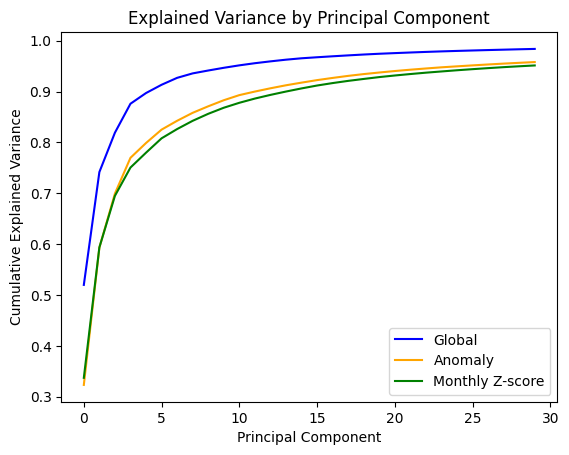

In [62]:
import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca_global.explained_variance_ratio_), color="blue")
plt.plot(np.cumsum(pca_anom.explained_variance_ratio_), color="orange")
plt.plot(np.cumsum(pca_month_z.explained_variance_ratio_), color="green")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Component")
plt.legend(["Global", "Anomaly", "Monthly Z-score"])
plt.show()


In [63]:
import matplotlib.pyplot as plt
import calendar

def plot_pca(scores, pca, title):
    fig, ax = plt.subplots(figsize=(10, 8))

    scatter = ax.scatter(
        scores["PC1"],
        scores["PC2"],
        c=scores["month"],
        cmap="hsv",
        alpha=0.65,
        s=30,
    )

    # Calendar-month centroids
    for month in range(1, 13):
        subset = scores[scores["month"] == month]

        ax.text(
            subset["PC1"].mean(),
            subset["PC2"].mean(),
            calendar.month_abbr[month],
            fontsize=11,
            fontweight="bold",
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")

    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

    ax.set_title(title)

    plt.show()

In [ ]:
plot_pca(
    scores_global,
    pca_global,
    "Global standardization",
)
plot_pca(
    scores_anom,
    pca_anom,
    "Monthly climatology removed",
)
plot_pca(
    scores_month_z,
    pca_month_z,
    "Monthly climatology + monthly scaling",
)


In [67]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


@dataclass
class MonthlyPCATransformer:
    variables: list[str]

    climatology: xr.DataArray
    anomaly_std: xr.DataArray

    pca: PCA

    feature_index: pd.Index
    era5_scores: pd.DataFrame



def fit_monthly_pca(
    X: xr.DataArray,
    n_components: int = 20,
):
    """
    X:
        DataArray with dimensions
        (time, feature)

    Features already correspond to the exact desired:
        variable × latitude × longitude
    structure.
    """

    # --------------------------------------------------
    # 1. Monthly climatology
    # --------------------------------------------------

    climatology = X.groupby("time.month").mean("time")

    # --------------------------------------------------
    # 2. Remove monthly climatology
    # --------------------------------------------------

    anomalies = X.groupby("time.month") - climatology

    # --------------------------------------------------
    # 3. One residual SD per feature
    # --------------------------------------------------

    anomaly_std = anomalies.std("time")

    anomaly_std = xr.where(
        anomaly_std > 0,
        anomaly_std,
        1.0,
    )

    Z = anomalies / anomaly_std

    # --------------------------------------------------
    # 4. PCA
    # --------------------------------------------------

    n_components = min(
        n_components,
        Z.sizes["time"] - 1,
        Z.sizes["feature"],
    )

    pca = PCA(
        n_components=n_components,
    )

    scores = pca.fit_transform(Z.values)

    # --------------------------------------------------
    # 5. Store historical PCA positions
    # --------------------------------------------------

    score_df = pd.DataFrame(
        scores,
        index=pd.DatetimeIndex(X.time.values),
        columns=[f"PC{i + 1}" for i in range(n_components)],
    )

    return MonthlyPCATransformer(
        variables=[],
        climatology=climatology,
        anomaly_std=anomaly_std,
        pca=pca,
        feature_index=X.indexes["feature"],
        era5_scores=score_df,
    )


def transform_month(
    transformer: MonthlyPCATransformer,
    X: xr.DataArray,
    month: int ,
):
    """
    X must have dimension 'feature'
    and exactly the same features as the ERA5 training data.
    """

    # Ensure identical feature order
    X = X.sel(feature=transformer.feature_index)

    climatology = transformer.climatology.sel(month=month)

    # ERA5-consistent anomaly
    anomaly = X - climatology

    # ERA5 residual scaling
    Z = anomaly / transformer.anomaly_std

    # sklearn expects samples × features
    values = np.asarray(Z.values)

    if values.ndim == 1:
        values = values[None, :]

    return transformer.pca.transform(values)

In [68]:
PCA_obj = fit_monthly_pca(X, n_components=10)


pc = transform_month(
    PCA_obj,
    SEAS5_X,  # SEAS5_X
    month=1,
)


In [69]:
def nearest_candidates(
    transformer,
    forecast_pc,
    month : int | None = None,
    n : int =10,
):
    scores = transformer.era5_scores

    # Same calendar month only
    
    candidates = scores if month is None else scores[scores.index.month == month]

    pc_columns = [c for c in candidates.columns if c.startswith("PC")]

    X = candidates[pc_columns].values

    forecast_pc = np.asarray(forecast_pc).reshape(1, -1)

    distances = np.linalg.norm(
        X - forecast_pc,
        axis=1,
    )

    result = pd.DataFrame(
        {
            "time": candidates.index,
            "distance": distances,
        }
    )

    return result.sort_values("distance").head(n).reset_index(drop=True)


In [75]:
a =nearest_candidates(
    PCA_obj,
    forecast_pc=pc[0],
    month=1,
    n=100,
)


In [148]:
import matplotlib.pyplot as plt
import calendar


def plot_pca_candidates(transformer, forecast_pc, title, month, year):
    fig, ax = plt.subplots(figsize=(10, 8))


    scores = transformer.era5_scores
    # Same calendar month only
    candidates = scores if month is None else scores[scores.index.month == month]
    pc_columns = [c for c in candidates.columns if c.startswith("PC")]
    X = candidates[pc_columns].values
    forecast_pc = np.asarray(forecast_pc).reshape(1, -1)
    distances = np.linalg.norm(
        X - forecast_pc,
        axis=1,
    )
    result = pd.DataFrame(
        {
            "time": candidates.index,
            "distance": distances,
        }
    )
    candidates = result.sort_values("distance").head(100).reset_index(drop=True)

    scores = transformer.era5_scores.loc[candidates.time.values,:]

    scatter = ax.scatter(
        scores["PC1"],
        scores["PC2"],
        c="blue",
        cmap="hsv",
        alpha=0.65,
        s=30,
    )
    for idx, row in scores.iterrows():
        ax.annotate(
            idx.strftime("%Y-%m"),
            xy=(row["PC1"], row["PC2"]),
            xytext=(0, 6),
            textcoords="offset points",
            fontsize=9,
            ha="center",
        )

    scatter2 = ax.scatter(
            forecast_pc[0][0],
            forecast_pc[0][1],
            c="red",
            cmap="hsv",
            alpha=1,
            s=30,
        )
    ax.annotate(
        f"{year}-{month:02d}",
        xy=(forecast_pc[0][0],        forecast_pc[0][1]),
        xytext = (0,6),
        textcoords="offset points",
        fontsize=12,
        ha="center",

    )

    ax.set_xlabel(f"PC1 ({transformer.pca.explained_variance_ratio_[0]:.1%})")

    ax.set_ylabel(f"PC2 ({transformer.pca.explained_variance_ratio_[1]:.1%})")

    ax.set_title(title)
    plt.show()


/tmp/ipykernel_746940/4232750707.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(
/tmp/ipykernel_746940/4232750707.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter2 = ax.scatter(


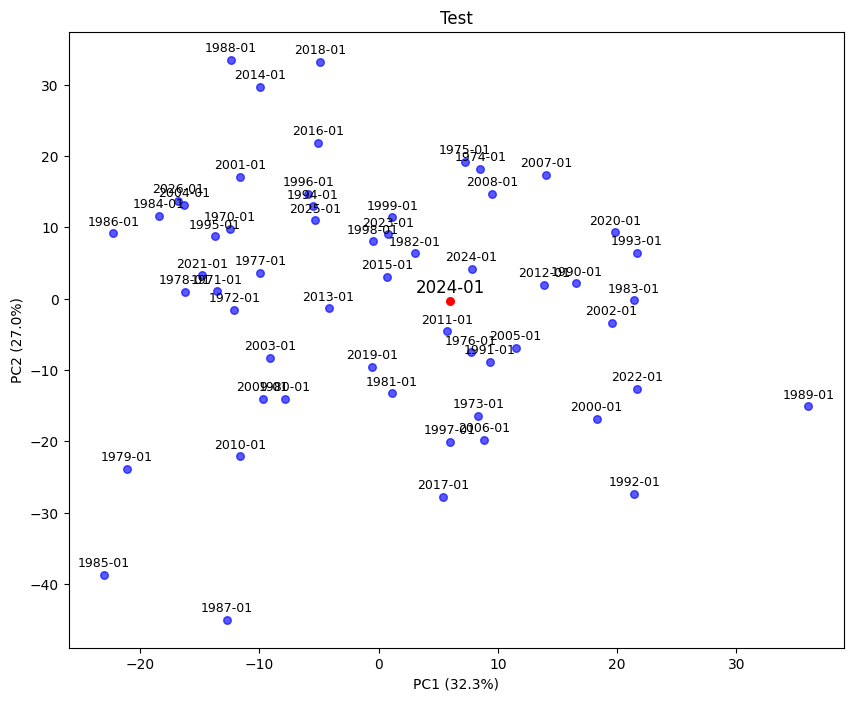

In [149]:
a = plot_pca_candidates(transformer=PCA_obj, forecast_pc=pc, title="Test", month=1, year=2024)

## Production pooled-anomaly PCA API

The exploratory PCA comparisons above are intentionally kept unchanged. The production SEAS5 pipeline now uses the same preferred idea: **one PCA fitted to all calendar-month anomalies**, with analog selection restricted to the same calendar month afterwards.

In [ ]:
from irrigator.forecasts.pca_framework import (
    fit_regional_anomaly_pca,
    transform_to_regional_pca,
    rank_regional_analogs,
    plot_regional_pca_candidates,
)

# One PCA basis, estimated from the complete ERA5 monthly anomaly archive.
france_pca = fit_regional_anomaly_pca(
    era5_1deg,
    variables=VARIABLES,
    n_components=10,
    spatial_mask=france_mask,
)

print(france_pca.explained_variance_ratio)


In [ ]:
# Diagnostic example: place one SEAS5 member/month in the same PCA space.
# Keeping TARGET_YEAR / TARGET_MONTH explicit is useful for the 2-D visual test.
TARGET_YEAR = 2024
TARGET_MONTH = 1

seas5_target = seas5_france.isel(number=0, forecastMonth=0, drop=True)[VARIABLES]
target_time = np.datetime64(f"{TARGET_YEAR:04d}-{TARGET_MONTH:02d}-01")
if "time" in seas5_target.dims:
    if seas5_target.sizes["time"] != 1:
        raise ValueError("Select one SEAS5 initialization/time before PCA projection.")
    seas5_target = seas5_target.assign_coords(time=[target_time])
else:
    seas5_target = seas5_target.expand_dims(time=[target_time])

forecast_pc = transform_to_regional_pca(
    seas5_target,
    france_pca,
    VARIABLES,
)

candidates = rank_regional_analogs(
    france_pca,
    forecast_pc,
    top_k=20,
    metric="euclidean",
)
display(candidates)

plot_regional_pca_candidates(
    france_pca,
    forecast_pc.values[0],
    month=TARGET_MONTH,
    year=TARGET_YEAR,
    top_n=None,  # full same-month reanalysis cloud for visualization
)
